In [1]:
import torch
from data_setup import create_dataloaders, visualize_sample_image_from_dataloader
from torchvision import transforms

Processing batches: 100%|██████████| 1/1 [00:00<00:00, 38.62it/s]


Concatenating batches...
Concatenated 1770 rows. Adding labels...
Resetting index...
Data processing complete.


Checking image sources: 100%|██████████| 1770/1770 [00:00<00:00, 11618.97it/s]


Splitting train/val...
Train: 1593, Val: 177
Fixing train paths...


Fixing paths (train): 100%|██████████| 1593/1593 [00:00<00:00, 108360.79it/s]


Fixing val paths...


Fixing paths (validation): 100%|██████████| 177/177 [00:00<00:00, 87888.22it/s]


label
genuine    1403
fraud       190
Name: count, dtype: int64

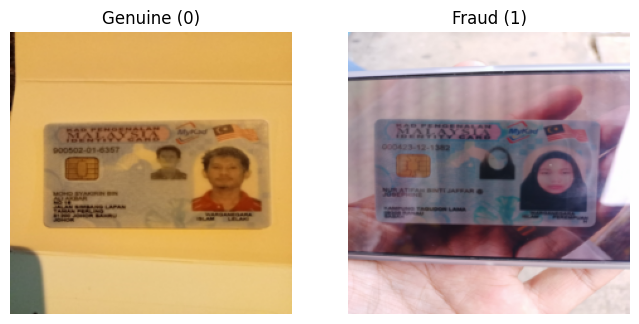

In [2]:
train_batch = [ "batch_production_202207_redone_rejectedcase/index_annotation.csv",
				#"batch_production_202209_redone_rejectedcase/index_annotation.csv",
				#"batch_legacy_20221026_subset/index_annotation_ori.csv",
                ]

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_dataset, validation_dataset, train_loader, validation_loader, class_names  = create_dataloaders(train_list=train_batch, transform=transform, batch_size=4)

# try out the train_dataset (Custom pytorch dataset object)
display(train_dataset.label_counts())

visualize_sample_image_from_dataloader(train_loader)

In [ ]:
# Add this to your notebook after the dataloader setup

from model_builder import CustomClassifierModel
from engine import train
import torch.nn as nn

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_DIR = "/home/jingjie/DinoFT/dinov3"
CHECKPOINT_PATH = "/home/jingjie/DinoFT/DinoClassifier/models/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"

# Load backbone
dinov3_vits16 = torch.hub.load(REPO_DIR, 'dinov3_vits16', source='local', weights=CHECKPOINT_PATH)

# Create model
model = CustomClassifierModel(
    backbone_model=dinov3_vits16,
    backbone_model_output_dim=384,
    freeze_backbone=False  # freeze for faster testing
).to(device)

# Train
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

results = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=validation_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,  # quick test
    device=device
)

 10%|█         | 1/10 [00:19<02:53, 19.24s/it]

Epoch: 1 | train_loss: 0.3327 | train_acc: 0.8845 | train_apcer: 0.9211 | train_bpcer: 0.0064 | test_loss: 0.2902 | test_acc: 0.8814 | test_apcer: 1.0000 | test_bpcer: 0.0000


 20%|██        | 2/10 [00:38<02:32, 19.02s/it]

Epoch: 2 | train_loss: 0.3249 | train_acc: 0.8845 | train_apcer: 0.9316 | train_bpcer: 0.0050 | test_loss: 0.2542 | test_acc: 0.8870 | test_apcer: 0.9524 | test_bpcer: 0.0000


 30%|███       | 3/10 [00:57<02:13, 19.03s/it]

...

Epoch: 8 | train_loss: 0.0601 | train_acc: 0.9780 | train_apcer: 0.0789 | train_bpcer: 0.0143 | test_loss: 0.1144 | test_acc: 0.9492 | test_apcer: 0.3333 | test_bpcer: 0.0128


 90%|█████████ | 9/10 [02:48<00:18, 18.74s/it]

Epoch: 9 | train_loss: 0.0672 | train_acc: 0.9736 | train_apcer: 0.1053 | train_bpcer: 0.0157 | test_loss: 0.1199 | test_acc: 0.9492 | test_apcer: 0.3810 | test_bpcer: 0.0064


100%|██████████| 10/10 [03:02<00:00, 18.28s/it]

Epoch: 10 | train_loss: 0.0492 | train_acc: 0.9805 | train_apcer: 0.0842 | train_bpcer: 0.0107 | test_loss: 0.2202 | test_acc: 0.9322 | test_apcer: 0.5714 | test_bpcer: 0.0000
